In [1]:
# we use "polynomial-logistic-regression" for "NON-LINEAR DATA"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('ushape.csv')

In [4]:
df.head()

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1200,-0.0462,1.0
2,0.8820,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8300,-0.5390,1.0


In [5]:
# extracting the values of 'X' and 'y'

X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
print(y[:5])
print(y.dtype)

[0. 1. 0. 1. 1.]
float64


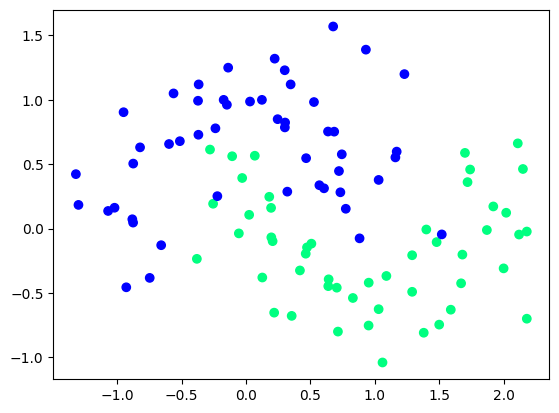

In [7]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter')

# X[:, 0] → takes all rows, column 0 (first feature)
# X[:, 1] → takes all rows, column 1 (second feature)
# c=y → colors each point based on its class label (y)

In [8]:
# Now, Apply Smiple Logistic Regression class here

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

In [9]:
clf.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


<Axes: >

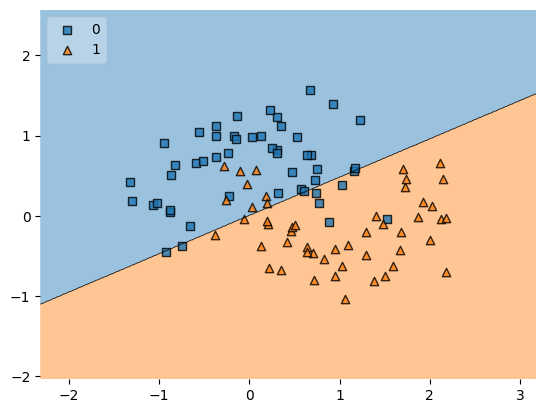

In [10]:
# So,if we try it with simple 'logistic_Regression',then it draws a simple line(passing through it) to classify the data.

# So, this is our "decision boundary" for this model :-

from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y.astype('int'), clf, legend=2)

In [11]:
# let's check for it's accuracy_score

from sklearn.model_selection import cross_val_score

np.mean(cross_val_score(clf, X, y, scoring='accuracy',cv=10))

0.8300000000000001

In [12]:
# Now, the question is "Can we improve this 'Accuracy_Score ??", so answer is YES.

In [13]:
# we make a class of 'Polynomial_Features' with name "poly" :-

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)

X_trf = poly.fit_transform(X)

In [14]:
clf1 = LogisticRegression()
np.mean(cross_val_score(clf1, X_trf, y, scoring='accuracy', cv=10))

0.9

In [15]:
# So, now our Accuracy increases here.

In [16]:
# making a function which gives 'decision_boundary' by entering a degree value

def plot_decision_boundary(X,y,degree=1):     # we take here (degree=1) as a default value.

    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)

    clf = LogisticRegression()
    clf.fit(X_trf, y)

    accuracy = np.mean(cross_val_score(clf, X_trf, y, scoring='accuracy', cv=10))

    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

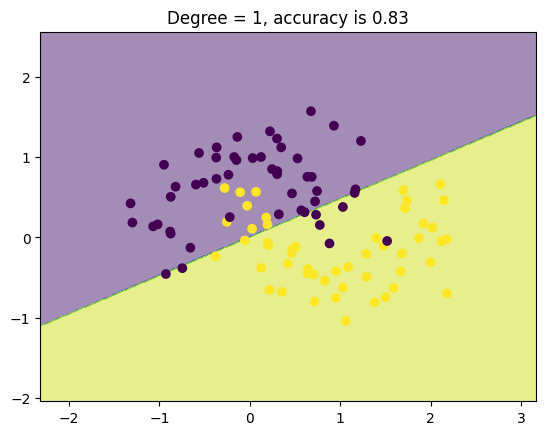

In [17]:
# Now, start plotting different 'decision_boundary' by giving "degree_value".

plot_decision_boundary(X,y)     # here, degree=1 (by default)

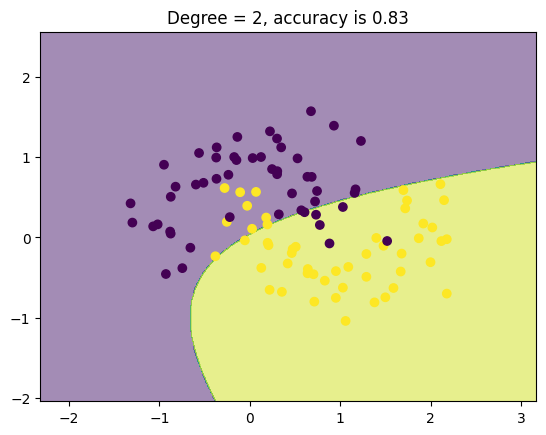

In [18]:
# for degree=2, 'decision_boundary' is:-

plot_decision_boundary(X,y,degree=2)

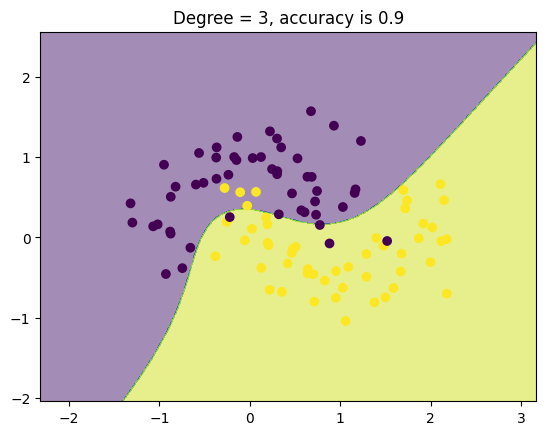

In [19]:
# for degree=3, 'decision_boundary' is:-

plot_decision_boundary(X,y,degree=3)

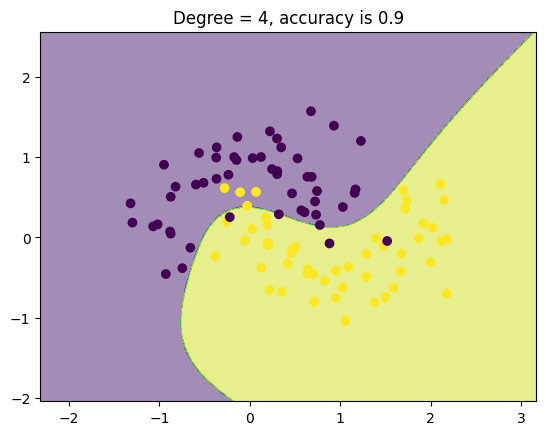

In [20]:
# for degree=4, 'decision_boundary' is:-

plot_decision_boundary(X,y,degree=4)

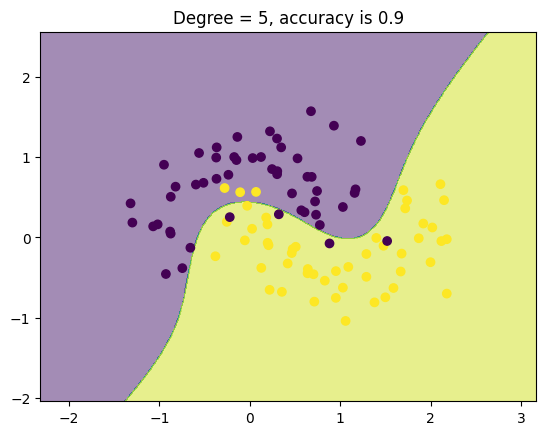

In [21]:
# for degree=5, 'decision_boundary' is:-

plot_decision_boundary(X,y,degree=5)

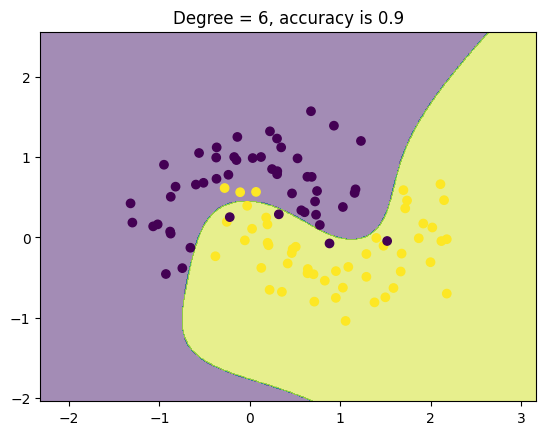

In [22]:
# for degree=6, 'decision_boundary' is:-

plot_decision_boundary(X,y,degree=6)

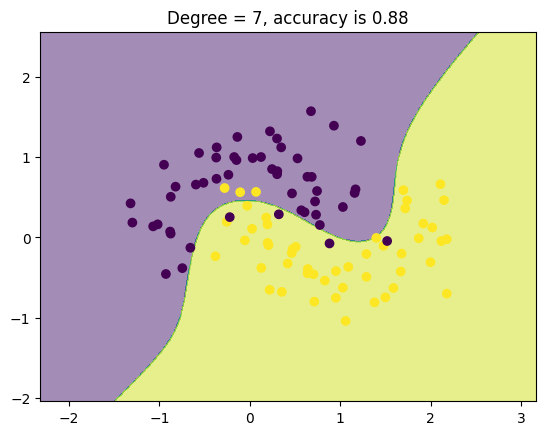

In [23]:
# for degree=7, 'decision_boundary' is:-

plot_decision_boundary(X,y,degree=7)

C:\Users\munna\anaconda3\envs\profiling310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\munna\anaconda3\envs\profiling310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

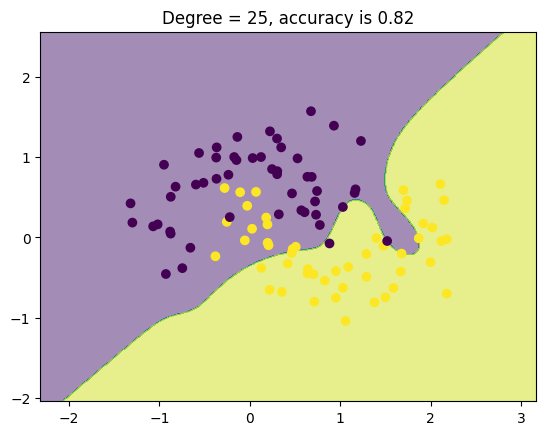

In [24]:
# for degree=25, 'decision_boundary' is:-

plot_decision_boundary(X,y,degree=25)

In [25]:
# So, we can see, it perfectly works only for (degree=3,5,7).

# So, that's why we take the help of other algorithms(like Decision Tree, Random Forest etc..). 